In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Cargar el archivo CSV
df = pd.read_excel("IPH_robos_2015_2025_tecmty.xlsx")

# 1. Preprocesamiento: Convertir la variable objetivo 'VIOLENCIA' a numérica (SI=1, NO=0)
df['VIOLENCIA_NUM'] = df['VIOLENCIA'].apply(lambda x: 1 if x == 'SI' else 0)

# 2. Ingeniería de Características: Codificación One-Hot para variables categóricas
categorical_cols = ['TIPO', 'DISTRITO', 'NOMBRE_DIA']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Definir las variables predictoras (X) y la variable objetivo (y)
features = ['AÑO', 'MES', 'DIA', 'HORA'] + [col for col in df_encoded.columns if col.startswith(('TIPO_', 'DISTRITO_', 'NOMBRE_DIA_'))]
X = df_encoded[features]
y = df_encoded['VIOLENCIA_NUM']

# 4. Manejar valores infinitos o NaN (si los hubiera)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())

# 5. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Crear y entrenar el modelo de Regresión Logística
logreg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# 7. Realizar predicciones
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

print("Modelo de Regresión Logística entrenado.")

Modelo de Regresión Logística entrenado.



### Matriz de Confusión (etiquetas: 0=NO Violencia, 1=SI Violencia) ###
[[5425  186]
 [1190  222]]


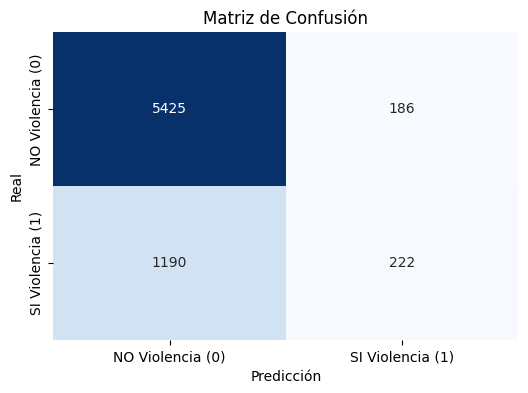

In [3]:
# Calcular la matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)

print("\n### Matriz de Confusión (etiquetas: 0=NO Violencia, 1=SI Violencia) ###")
print(conf_mat)

# Visualización de la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['NO Violencia (0)', 'SI Violencia (1)'],
            yticklabels=['NO Violencia (0)', 'SI Violencia (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [4]:
# Generar el reporte de clasificación
class_report = classification_report(y_test, y_pred, target_names=['NO Violencia (0)', 'SI Violencia (1)'])

print("\n### Reporte de Clasificación ###")
print(class_report)


### Reporte de Clasificación ###
                  precision    recall  f1-score   support

NO Violencia (0)       0.82      0.97      0.89      5611
SI Violencia (1)       0.54      0.16      0.24      1412

        accuracy                           0.80      7023
       macro avg       0.68      0.56      0.57      7023
    weighted avg       0.76      0.80      0.76      7023




### Área Bajo la Curva (AUC): 0.8288 ###


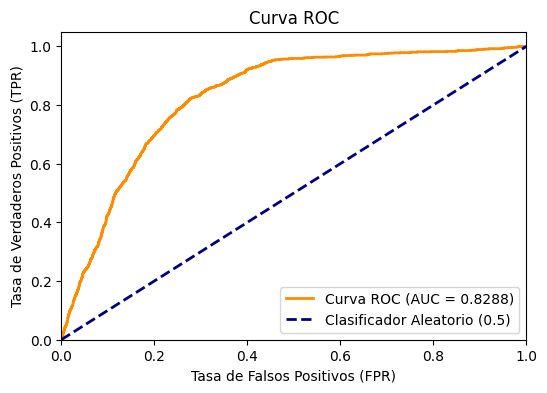

In [5]:
# Calcular la Tasa de Falsos Positivos (FPR), Tasa de Verdaderos Positivos (TPR) y Umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calcular el Área Bajo la Curva (AUC)
roc_auc = auc(fpr, tpr)

print(f"\n### Área Bajo la Curva (AUC): {roc_auc:.4f} ###")

# Visualización de la Curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()